In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("balanced_dataset.csv")

In [14]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

In [15]:
features = X.select_dtypes(include=["int64", "float64"]).columns

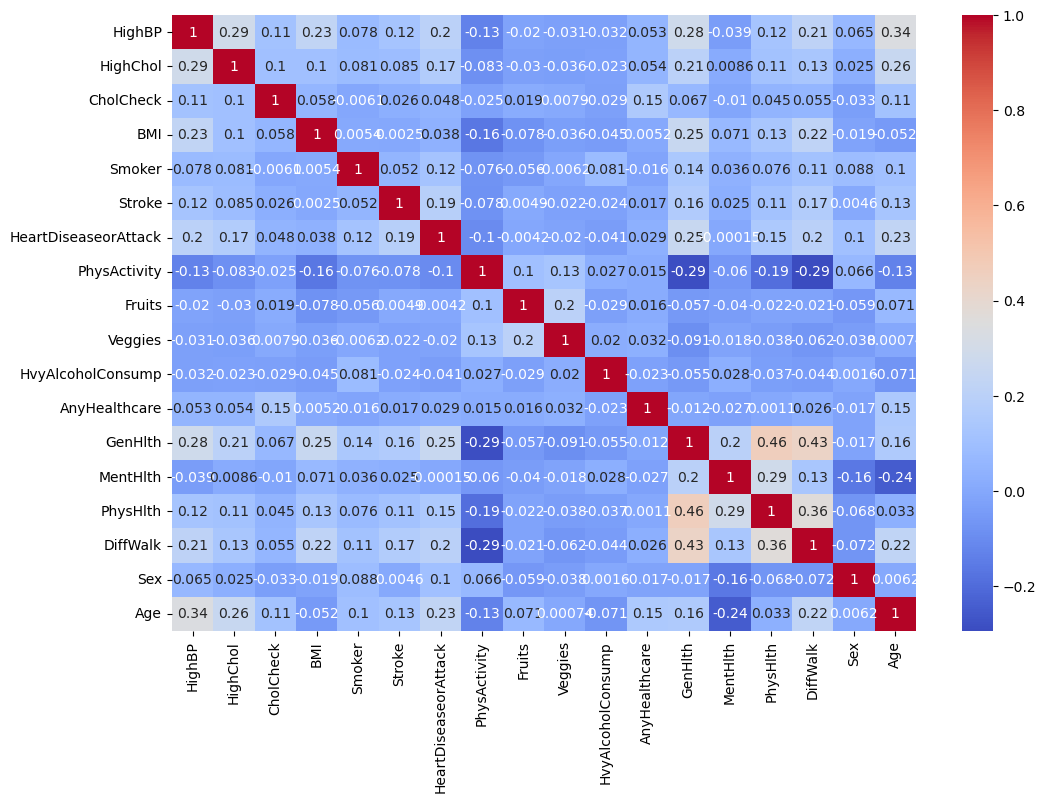

In [5]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

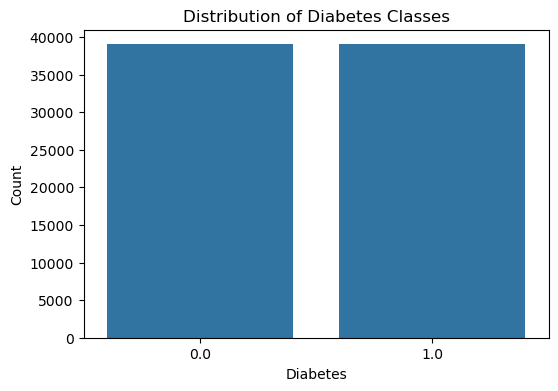

Diabetes_012
0.0    39008
1.0    39008
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="Diabetes_012", data=df)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

print(df["Diabetes_012"].value_counts())

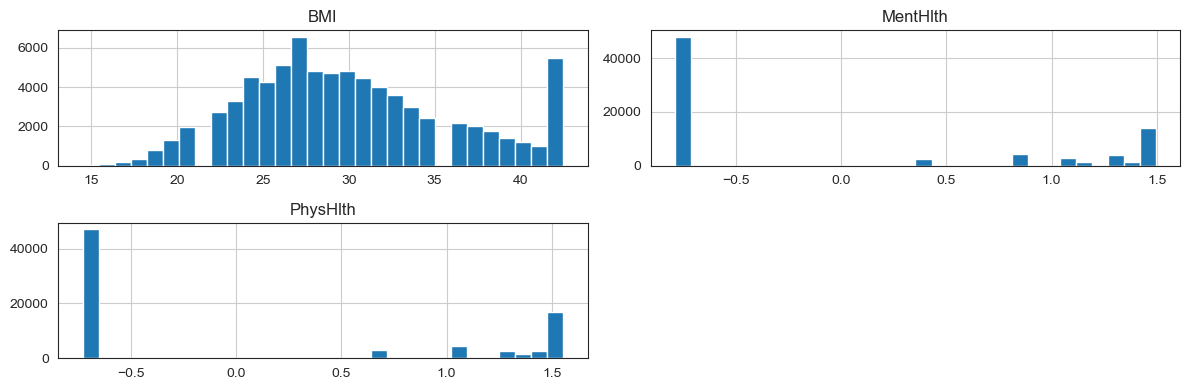

In [17]:
numerical_cols = [
    "BMI",
    "MentHlth",
    "PhysHlth",
]

df[numerical_cols].hist(
    figsize=(12,4),
    bins=30
)

plt.tight_layout()
plt.show()

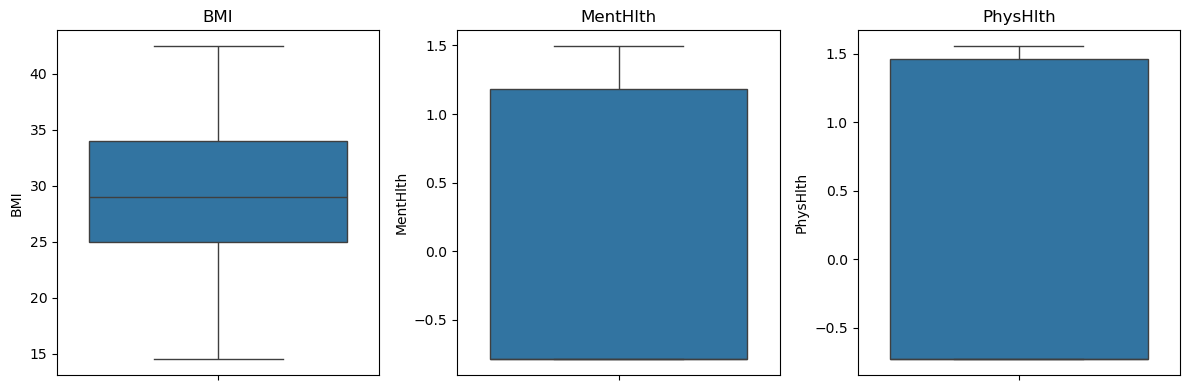

In [8]:
plt.figure(figsize=(12,4))

for i,col in enumerate(numerical_cols):

    plt.subplot(1,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

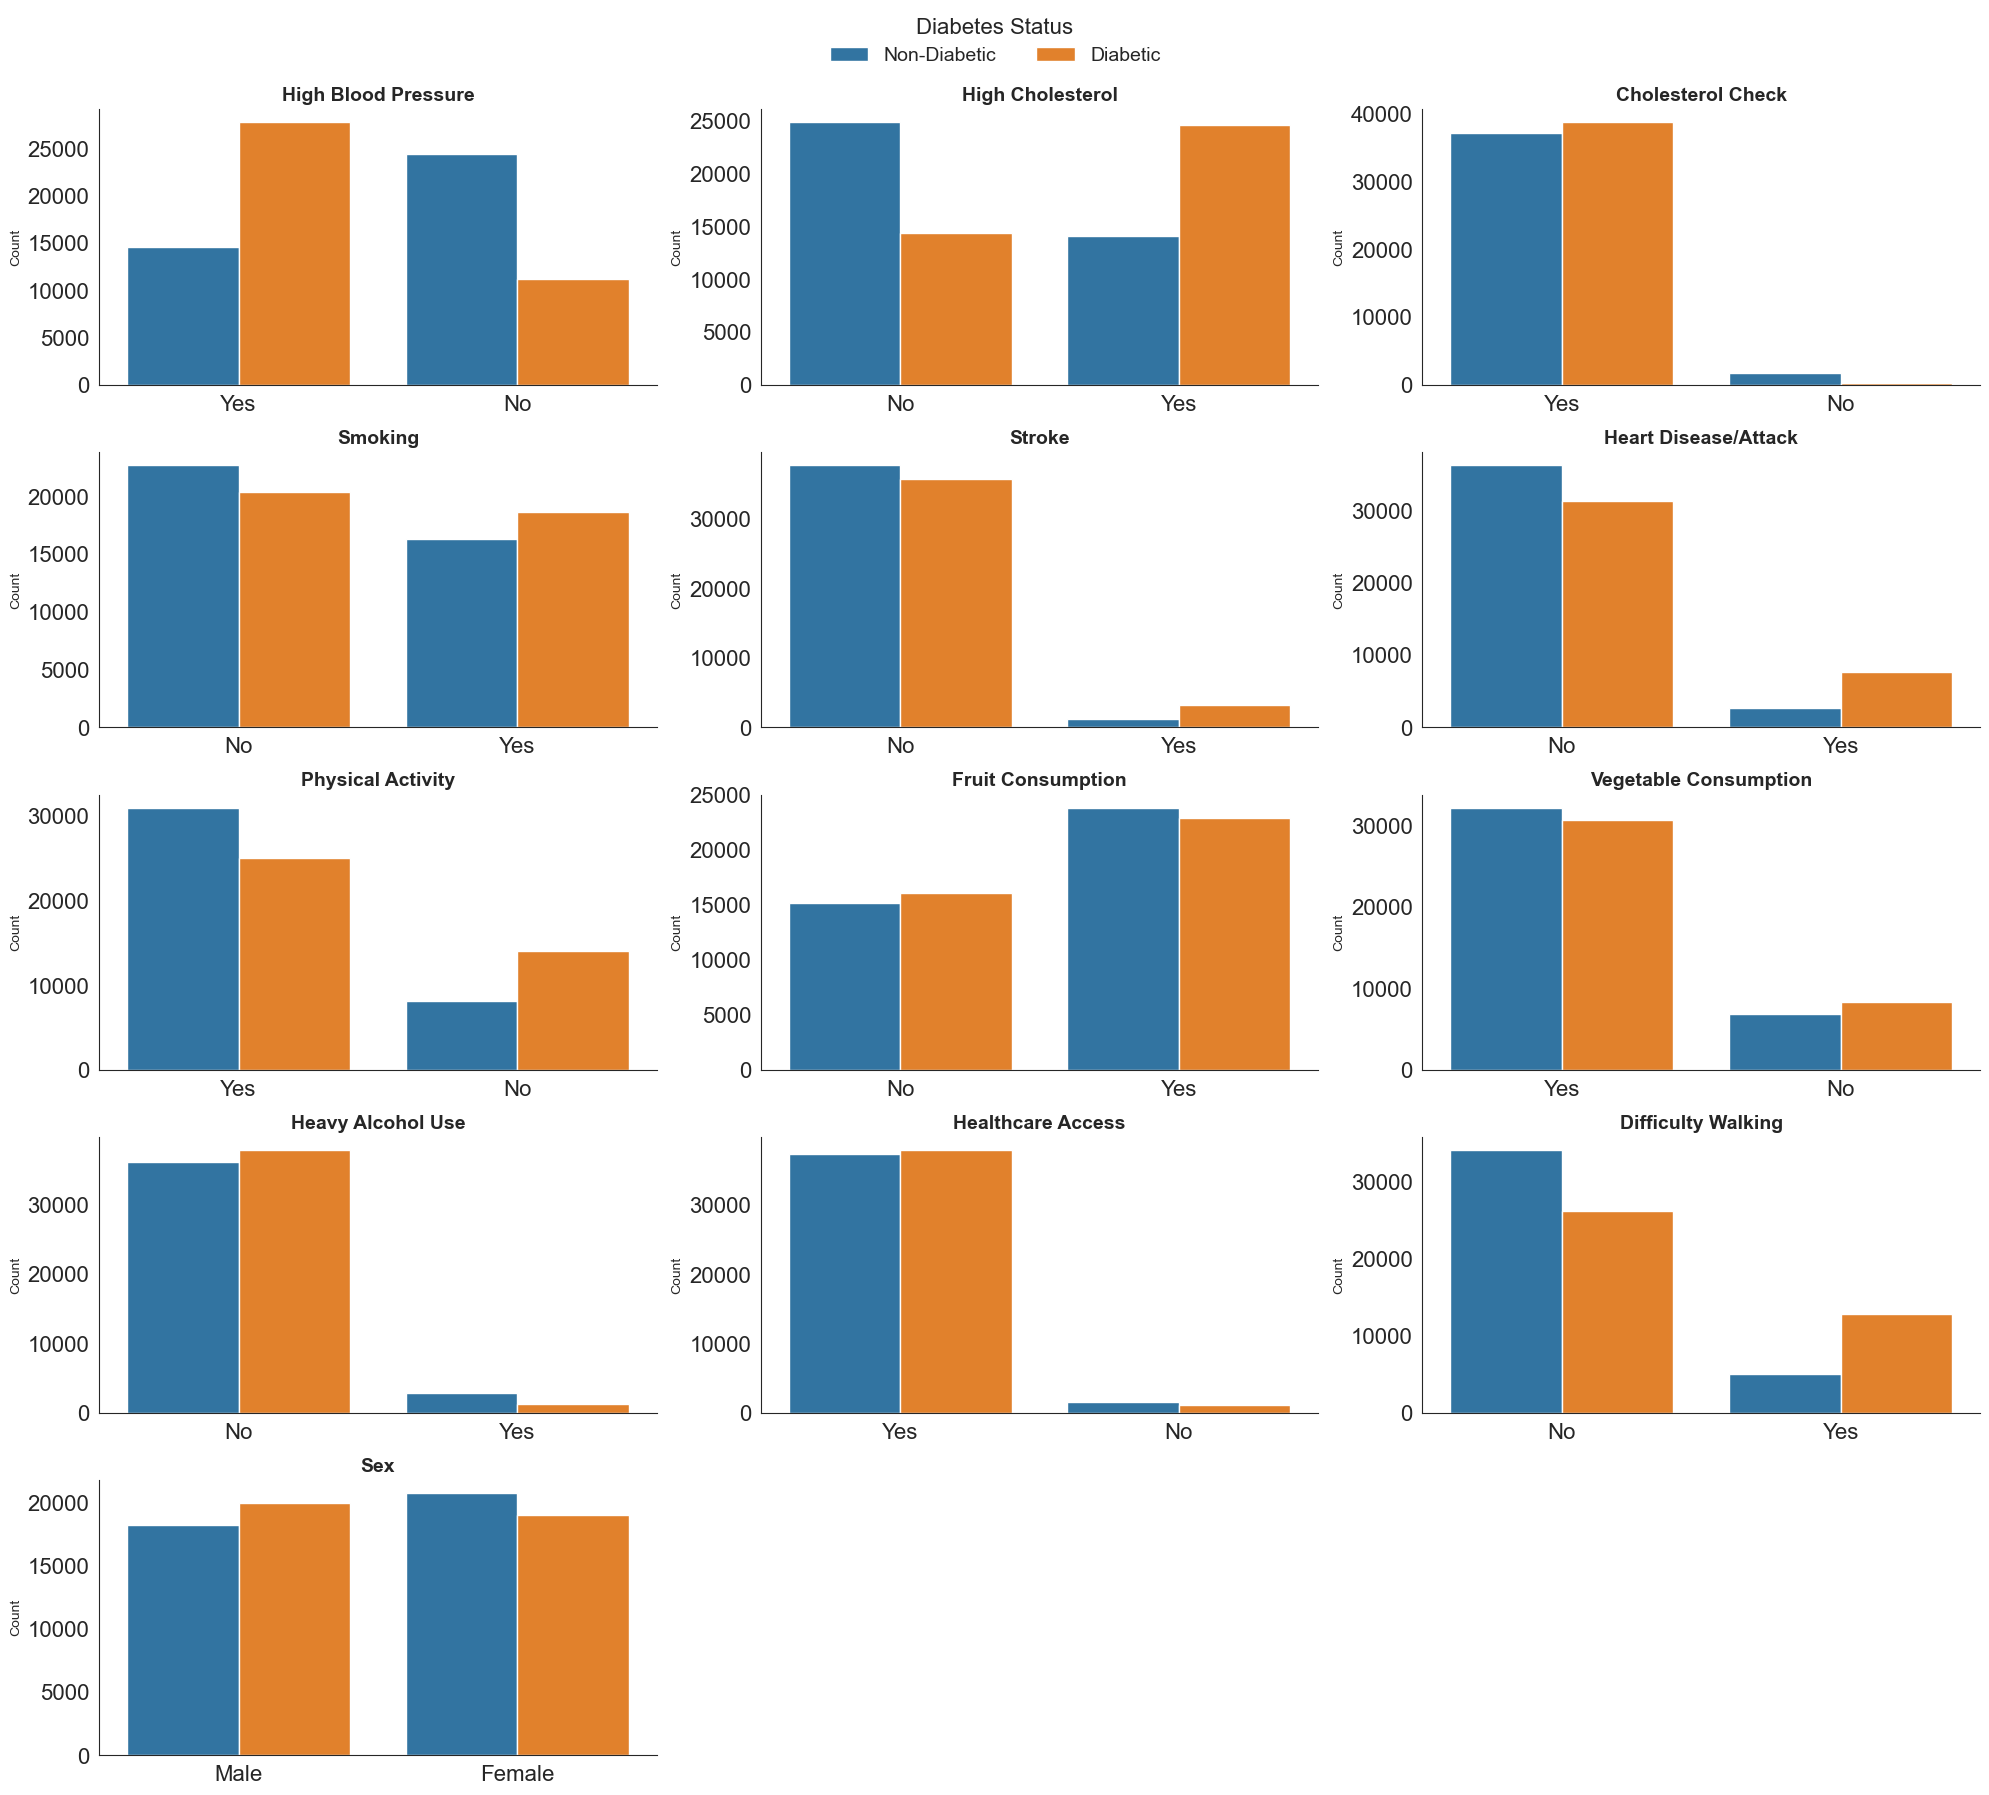

In [37]:
# -------------------------------
# Copy dataframe for plotting
# -------------------------------

plot_df = df.copy()

yes_no_cols = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits",
    "Veggies","HvyAlcoholConsump","AnyHealthcare","DiffWalk"
]

for col in yes_no_cols:
    plot_df[col] = plot_df[col].map({0: "No", 1: "Yes"})

plot_df["Sex"] = plot_df["Sex"].map({
    0: "Female",
    1: "Male"
})

plot_df["Diabetes_012"] = plot_df["Diabetes_012"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

# -------------------------------
# Columns to plot
# -------------------------------

categorical_cols = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits",
    "Veggies","HvyAlcoholConsump","AnyHealthcare",
    "DiffWalk","Sex"
]

# -------------------------------
# Better Titles
# -------------------------------

titles = {
    "HighBP":"High Blood Pressure",
    "HighChol":"High Cholesterol",
    "CholCheck":"Cholesterol Check",
    "Smoker":"Smoking",
    "Stroke":"Stroke",
    "HeartDiseaseorAttack":"Heart Disease/Attack",
    "PhysActivity":"Physical Activity",
    "Fruits":"Fruit Consumption",
    "Veggies":"Vegetable Consumption",
    "HvyAlcoholConsump":"Heavy Alcohol Use",
    "AnyHealthcare":"Healthcare Access",
    "DiffWalk":"Difficulty Walking",
    "Sex":"Sex"
}

# -------------------------------
# Plot
# -------------------------------

sns.set_style("white")

fig, axes = plt.subplots(5, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = axes[i]

    sns.countplot(
        data=plot_df,
        x=col,
        hue="Diabetes_012",
        ax=ax
    )

    ax.set_title(titles[col], fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    # Increase X-axis and Y-axis tick label size
    ax.tick_params(
        axis="x",
        labelsize=16
    )

    ax.tick_params(
        axis="y",
        labelsize=16
    )

    # Remove repeated legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Remove top and right borders
    sns.despine(ax=ax)

    # Remove grid
    ax.grid(False)

# -------------------------------
# Remove empty plots
# -------------------------------

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

# -------------------------------
# One common legend
# -------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Diabetes Status",
    loc="upper center",
    ncol=2,
    fontsize=14,
    title_fontsize=16,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [39]:
from scipy.stats import chi2_contingency

results = []

for col in categorical_cols:

    contingency = pd.crosstab(df[col], df["Diabetes_012"])

    chi2, p, dof, expected = chi2_contingency(contingency)

    results.append({
        "Feature": col,
        "Chi-square": round(chi2,2),
        "P-value": round(p,6),
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi_df = pd.DataFrame(results)

print(chi_df)

                 Feature  Chi-square  P-value Significant
0                 HighBP     8956.10      0.0         Yes
1               HighChol     5606.76      0.0         Yes
2              CholCheck     1219.82      0.0         Yes
3                 Smoker      276.89      0.0         Yes
4                 Stroke      922.76      0.0         Yes
5   HeartDiseaseorAttack     2699.83      0.0         Yes
6           PhysActivity     2251.42      0.0         Yes
7                 Fruits       49.90      0.0         Yes
8                Veggies      181.63      0.0         Yes
9      HvyAlcoholConsump      688.87      0.0         Yes
10         AnyHealthcare      114.48      0.0         Yes
11              DiffWalk     4457.26      0.0         Yes
12                   Sex      158.88      0.0         Yes


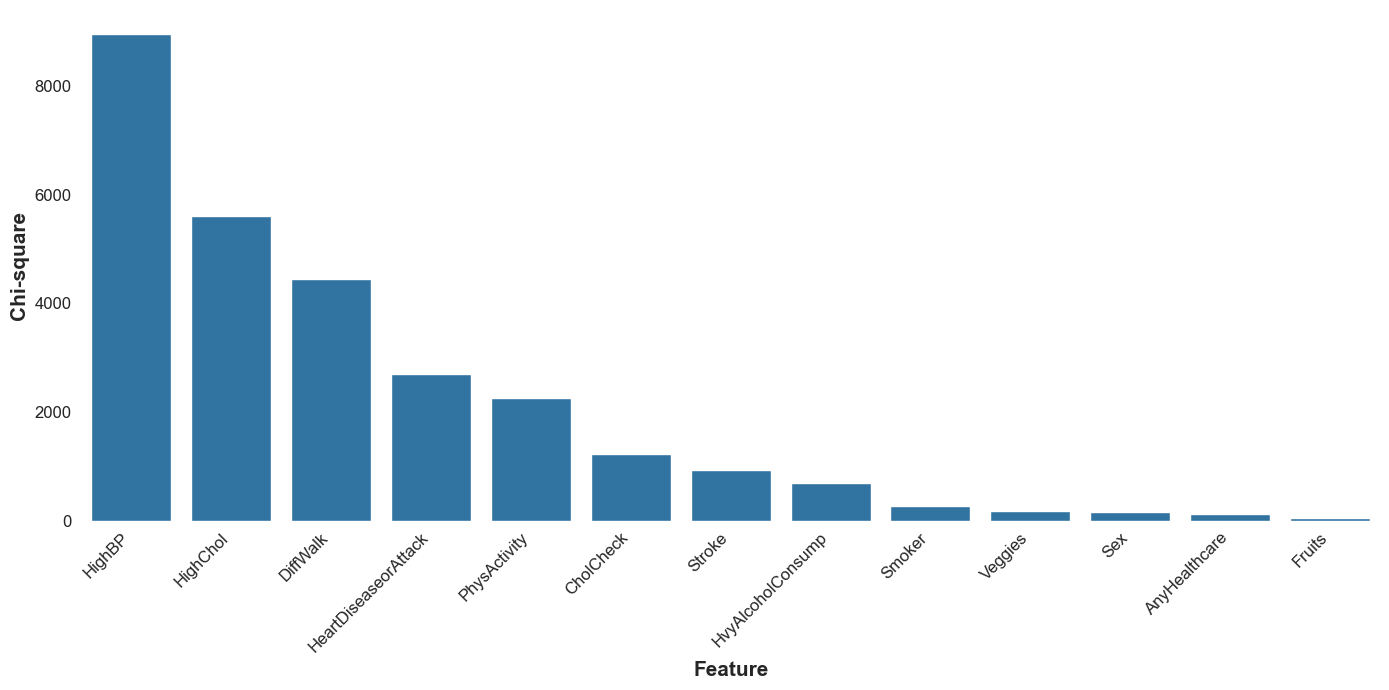

In [41]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=chi_df.sort_values("Chi-square", ascending=False),
    x="Feature",
    y="Chi-square"
)

# Axis labels
ax.set_xlabel(
    "Feature",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Chi-square",
    fontsize=15,
    fontweight="bold"
)

# Tick labels
ax.tick_params(
    axis="x",
    labelsize=12,
    rotation=45
)

ax.tick_params(
    axis="y",
    labelsize=12
)

# Make x-axis labels readable
plt.xticks(
    ha="right"
)

# Remove borders
sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=True,
    bottom=True
)

plt.tight_layout()

plt.show()

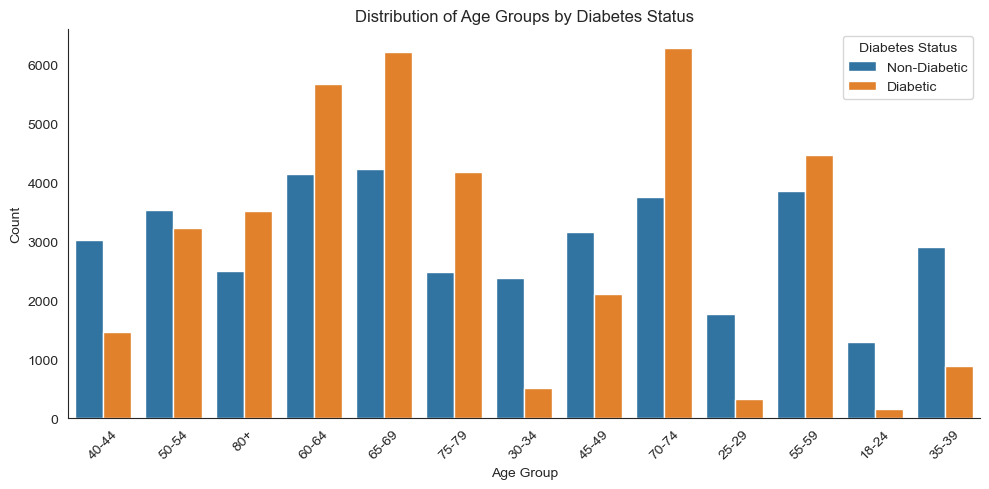

In [12]:
age_labels = [
    "18-24","25-29","30-34","35-39","40-44",
    "45-49","50-54","55-59","60-64",
    "65-69","70-74","75-79","80+"
]

plot_df = df.copy()

plot_df["Age"] = plot_df["Age"].map(dict(zip(range(1, 14), age_labels)))
plot_df["Diabetes_012"] = plot_df["Diabetes_012"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

plt.figure(figsize=(10,5))

sns.countplot(
    data=plot_df,
    x="Age",
    hue="Diabetes_012"
)

plt.title("Distribution of Age Groups by Diabetes Status")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Diabetes Status")

sns.despine()
plt.tight_layout()
plt.show()

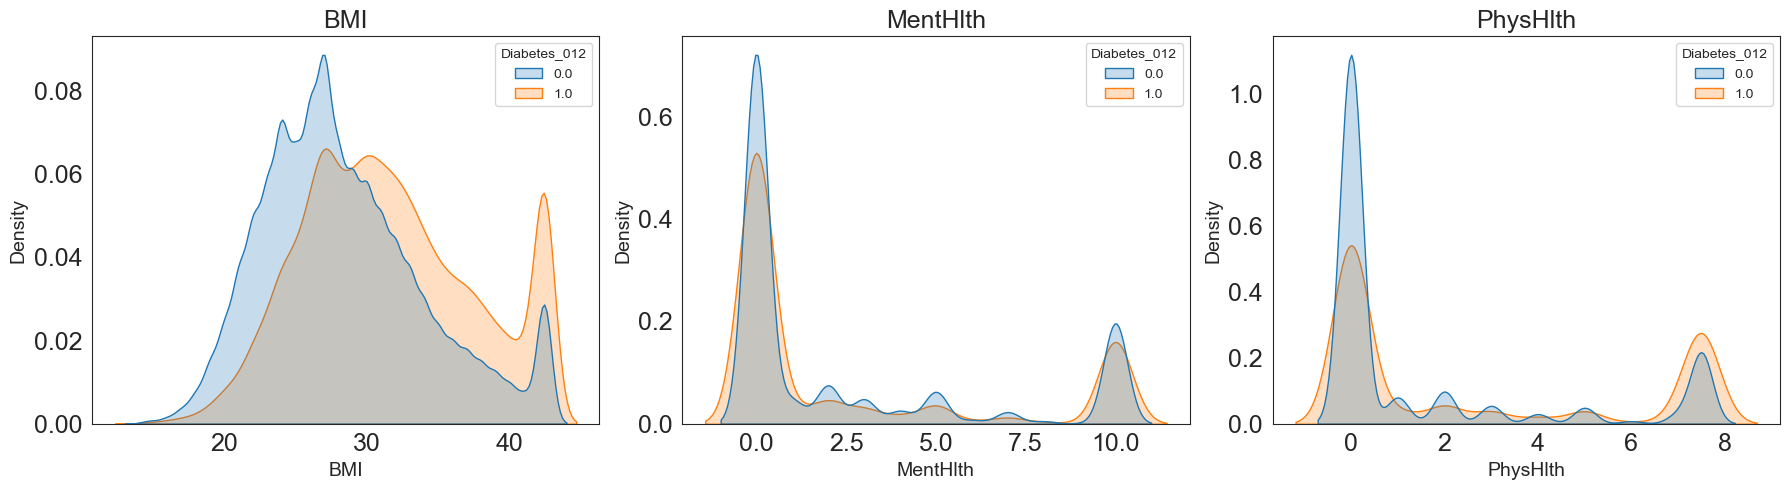

In [35]:
rd = pd.read_csv("outliers_treated.csv")

continuous_features = ["BMI", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numerical_cols):

    sns.kdeplot(
        data=rd,
        x=col,
        hue="Diabetes_012",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(
            col,
            fontsize=18,
        )
    
    axes[i].set_xlabel(
            col,
            fontsize=14,
        )
    
    axes[i].set_ylabel(
            "Density",
            fontsize=14,
        )
    
        # Increase tick-label size
    axes[i].tick_params(
            axis="x",
            labelsize=18
        )
    
    axes[i].tick_params(
        axis="y",
        labelsize=18
    )


plt.tight_layout()
plt.show()